In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import joblib

In [2]:
df = pd.read_csv(
    r"C:\Users\ravsi\Downloads\Conjunto de datos para 2a. evaluación-20260809\samsung.csv"
)

In [3]:
print("Forma:", df.shape)
print("Columnas:", df.columns.tolist())
print("Nulos:", df.isnull().sum().sum())
df.head()

Forma: (2850, 3)
Columnas: ['Date', 'Close', 'Volume']
Nulos: 0


,Date,Close,Volume
0,02/01/2008,10880,18047200
1,03/01/2008,10920,19346500
2,04/01/2008,10780,17997350
3,07/01/2008,10380,39787200
4,08/01/2008,10320,24783700


In [4]:
print(df.describe())

              Close        Volume
count   2850.000000  2.850000e+03
mean   26611.305263  1.610505e+07
std    11991.608543  8.661794e+06
min     8040.000000  0.000000e+00
25%    16300.000000  1.021426e+07
50%    25600.000000  1.359033e+07
75%    30850.000000  1.960970e+07
max    57220.000000  6.487345e+07


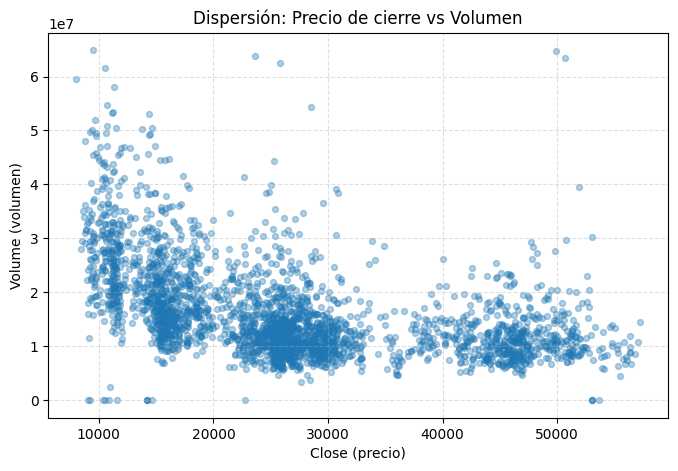

In [5]:
plt.figure(figsize=(8, 5))
plt.scatter(df["Close"], df["Volume"], alpha=0.35, s=18, color="#1f77b4")
plt.title("Dispersión: Precio de cierre vs Volumen")
plt.xlabel("Close (precio)")
plt.ylabel("Volume (volumen)")
plt.grid(True, linestyle="--", alpha=0.4)
plt.show()

In [6]:
X = df[["Close", "Volume"]].copy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print("Datos listos para K-Means. Forma:", X_scaled.shape)

Datos listos para K-Means. Forma: (2850, 2)


In [7]:
ks = range(2, 11)
inertias = []
silhouettes = []
for k in ks:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))

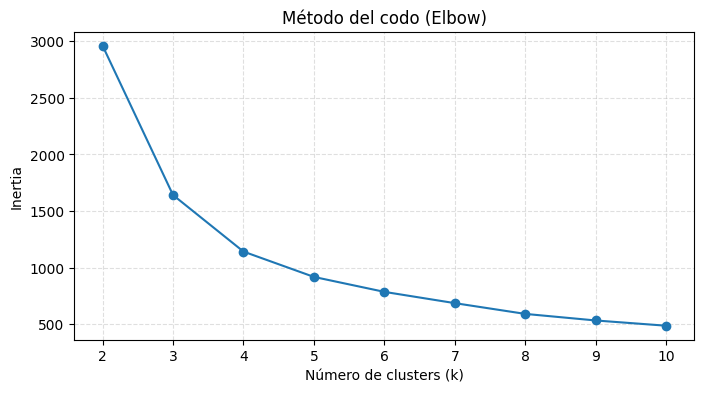

In [8]:
plt.figure(figsize=(8, 4))
plt.plot(list(ks), inertias, marker="o")
plt.title("Método del codo (Elbow)")
plt.xlabel("Número de clusters (k)")
plt.ylabel("Inertia")
plt.grid(True, linestyle="--", alpha=0.4)
plt.show()

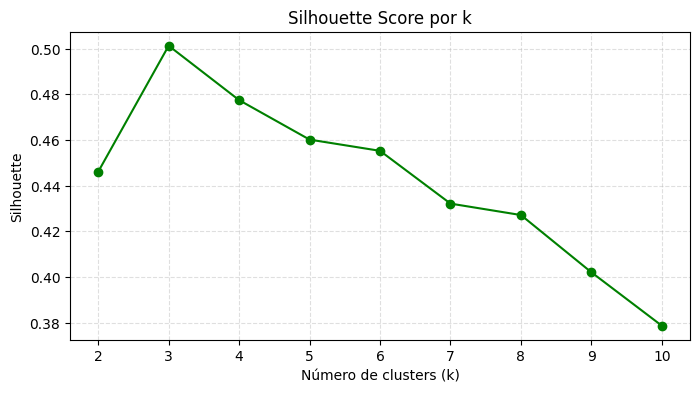

In [9]:
plt.figure(figsize=(8, 4))
plt.plot(list(ks), silhouettes, marker="o", color="green")
plt.title("Silhouette Score por k")
plt.xlabel("Número de clusters (k)")
plt.ylabel("Silhouette")
plt.grid(True, linestyle="--", alpha=0.4)
plt.show()

In [10]:
mejor_k = list(ks)[int(np.argmax(silhouettes))]
print("Silhouettes:", dict(zip(ks, np.round(silhouettes, 4))))
print("Mejor k según silhouette:", mejor_k)

Silhouettes: {2: np.float64(0.4461), 3: np.float64(0.5013), 4: np.float64(0.4774), 5: np.float64(0.4602), 6: np.float64(0.4552), 7: np.float64(0.4321), 8: np.float64(0.4271), 9: np.float64(0.4021), 10: np.float64(0.3787)}
Mejor k según silhouette: 3


In [11]:
mejor_modelo = KMeans(n_clusters=mejor_k, random_state=42, n_init=10)
clusters = mejor_modelo.fit_predict(X_scaled)
df_resultado = df.copy()
df_resultado["cluster"] = clusters
print("Tamaño de cada grupo:")
print(df_resultado["cluster"].value_counts().sort_index())
print("\nPromedios por grupo (Close y Volume):")
display(df_resultado.groupby("cluster")[["Close", "Volume"]].mean().round(2))
sil = silhouette_score(X_scaled, clusters)
print("\nSilhouette del modelo final:", round(sil, 4))

Tamaño de cada grupo:
cluster
0    1597
1     622
2     631
Name: count, dtype: int64

Promedios por grupo (Close y Volume):


,Close,Volume
cluster,,
0,23695.51,12782578.27
1,45833.34,11649825.62
2,15043.03,28905577.03



Silhouette del modelo final: 0.5013


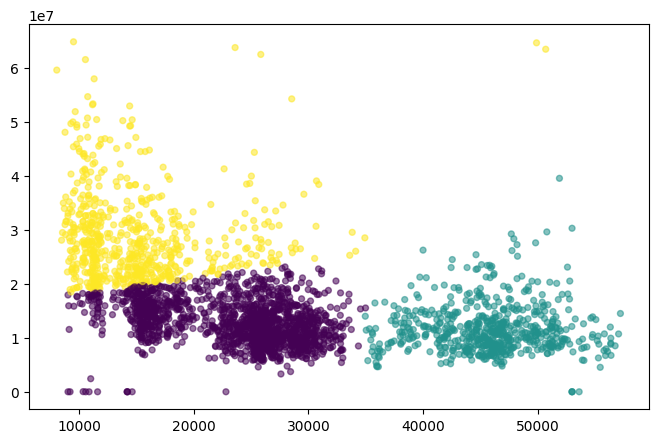

In [12]:
plt.figure(figsize=(8, 5))
scatter = plt.scatter(
    df_resultado["Close"],
    df_resultado["Volume"],
    c=df_resultado["cluster"],
    cmap="viridis",
    s=18,
    alpha=0.55
)


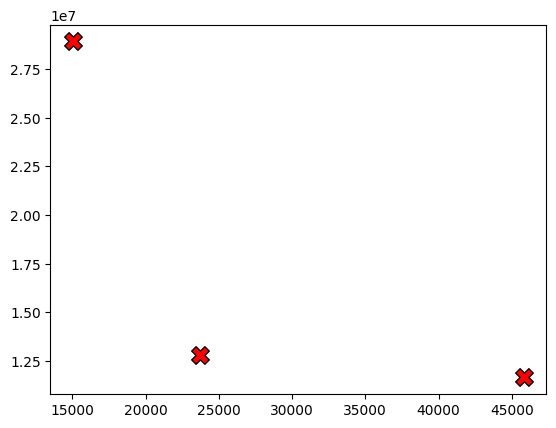

In [13]:
centros = scaler.inverse_transform(mejor_modelo.cluster_centers_)
plt.scatter(
    centros[:, 0], centros[:, 1],
    c="red", s=160, marker="X", edgecolors="black", label="Centros"
)

C:\Users\ravsi\AppData\Local\Temp\ipykernel_27064\3104755591.py:4: UserWarning: Adding colorbar to a different Figure <Figure size 800x500 with 2 Axes> than <Figure size 640x480 with 1 Axes> which fig.colorbar is called on.
  plt.colorbar(scatter, label="Cluster")
C:\Users\ravsi\AppData\Local\Temp\ipykernel_27064\3104755591.py:5: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


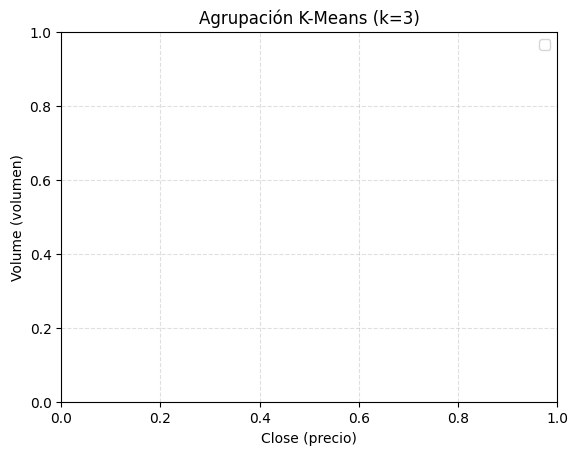

In [14]:
plt.title(f"Agrupación K-Means (k={mejor_k})")
plt.xlabel("Close (precio)")
plt.ylabel("Volume (volumen)")
plt.colorbar(scatter, label="Cluster")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.4)
plt.show()